# Word2Vec: Training Embeddings from Financial Text

**Chapter 10: Text Feature Engineering**
**Section Reference**: See Section 10.2 for embedding theory and distributional hypothesis

**Docker image**: `ml4t-py312`

> **Docker required**: This notebook uses `gensim`, which has no Python 3.14 support.
> Run with:
> ```bash
> docker compose --profile py312 run --rm py312 python 10_text_feature_engineering/01_word2vec_training.py
> ```

## Purpose
This notebook demonstrates how Word2Vec learns word embeddings from financial text.
Understanding the training process illuminates why the distributional hypothesis
works - and why the same principle extends to asset embeddings (stocks as words,
portfolios as documents).

## Learning Objectives
After completing this notebook, you will be able to:
- Train Word2Vec models using gensim (Skip-gram and CBOW)
- Understand hyperparameters: window size, embedding dimension, negative sampling
- Evaluate embeddings using word analogies
- Visualize learned embeddings with t-SNE
- Compare custom-trained vs pre-trained embeddings
- Connect Word2Vec mechanics to asset embedding intuition

## Prerequisites
- Section 10.2 of the chapter (distributional hypothesis, Word2Vec, GloVe).
- Familiarity with token-level NLP terminology (vocabulary, context window).

## Related Notebooks
- `02_asset_embeddings.py` - same Skip-gram machinery applied to 13F portfolios
- `03_sentiment_evolution.py` - compares static embeddings to TF-IDF and Transformers

In [1]:
"""Word2Vec: Training Embeddings from Financial Text - train and evaluate word embeddings on financial text."""

import contextlib
import io
import json
import warnings
from collections import Counter

import gensim.downloader as api
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from gensim.models import Word2Vec
from sklearn.manifold import TSNE

from data import load_financial_phrasebank as load_financial_phrasebank_canonical
from utils.paths import get_chapter_dir
from utils.reproducibility import set_global_seeds
from utils.style import COLORS

warnings.filterwarnings("ignore")

In [2]:
# Production defaults - Papermill injects overrides for CI
SEED = 42

In [3]:
# Reproducibility - single source of seeds for Python random, NumPy, and (if installed) Torch.
set_global_seeds(SEED)

CONFIG = {
    "random_seed": SEED,
    "word2vec": {
        "vector_size": 100,
        "window": 5,
        "min_count": 3,
        "sg": 1,  # 1 = Skip-gram, 0 = CBOW
        "negative": 10,  # Negative sampling
        "workers": 1,  # Use 1 for reproducibility (workers > 1 is non-deterministic)
        "epochs": 20,
    },
    "dataset": {
        "name": "takala/financial_phrasebank",
        "subset": "sentences_allagree",
    },
    "pretrained_comparison": "glove-wiki-gigaword-100",
}

print("=" * 70)
print("EXPERIMENT CONFIGURATION")
print("=" * 70)
print(json.dumps(CONFIG, indent=2))
print("=" * 70)

EXPERIMENT CONFIGURATION
{
  "random_seed": 42,
  "word2vec": {
    "vector_size": 100,
    "window": 5,
    "min_count": 3,
    "sg": 1,
    "negative": 10,
    "workers": 1,
    "epochs": 20
  },
  "dataset": {
    "name": "takala/financial_phrasebank",
    "subset": "sentences_allagree"
  },
  "pretrained_comparison": "glove-wiki-gigaword-100"
}


## The Core Insight: Distributional Hypothesis

**"You shall know a word by the company it keeps."** - J.R. Firth (1957)

Word2Vec operationalizes this: words appearing in similar contexts get
similar vector representations. The model learns by predicting:

- **Skip-gram**: Given a word, predict surrounding context words
- **CBOW**: Given context words, predict the center word

Both approaches push co-occurring words closer in embedding space.

## Load Financial Text Data

We use the Financial PhraseBank dataset - sentences from financial news
labeled for sentiment. This provides domain-specific vocabulary.

In [4]:
# Load Financial PhraseBank
def load_financial_phrasebank() -> pl.DataFrame:
    """Load Financial PhraseBank dataset from canonical local storage."""
    return load_financial_phrasebank_canonical()


print("Loading Financial PhraseBank...")
df = load_financial_phrasebank()
print(f"Loaded {len(df):,} sentences")
df.head()

Loading Financial PhraseBank...
Loaded 2,264 sentences


sentence,label
str,i64
"""According to Gran , the company has no plans to mo…",1
"""For the last quarter of 2010 , Componenta 's net s…",2
"""In the third quarter of 2010 , net sales increased…",2
"""Operating profit rose to EUR 13.1 mn from EUR 8.7 …",2
"""Operating profit totalled EUR 21.1 mn , up from EU…",2


In [5]:
# Simple tokenization for Word2Vec training
def tokenize(text: str) -> list[str]:
    """Basic tokenization: lowercase, split on whitespace, remove punctuation."""
    import re

    text = text.lower()
    text = re.sub(r"[^\w\s]", " ", text)
    tokens = text.split()
    return [t for t in tokens if len(t) > 1]


# Tokenize all sentences
sentences = [tokenize(s) for s in df["sentence"].to_list()]
print(f"Total sentences: {len(sentences):,}")
print(f"Total tokens: {sum(len(s) for s in sentences):,}")
print("\nSample tokenized sentence:")
print(sentences[0])

Total sentences: 2,264
Total tokens: 43,518

Sample tokenized sentence:
['according', 'to', 'gran', 'the', 'company', 'has', 'no', 'plans', 'to', 'move', 'all', 'production', 'to', 'russia', 'although', 'that', 'is', 'where', 'the', 'company', 'is', 'growing']


In [6]:
# Vocabulary analysis: raw token frequency before any min_count filter.
all_tokens = [t for s in sentences for t in s]
token_counts = Counter(all_tokens)
print(f"Distinct tokens before min_count filter: {len(token_counts):,}")

vocab_freq = pl.DataFrame(
    {
        "token": [t for t, _ in token_counts.most_common(15)],
        "count": [c for _, c in token_counts.most_common(15)],
    }
)
vocab_freq

Distinct tokens before min_count filter: 6,057


token,count
str,i64
"""the""",2730
"""of""",1525
"""in""",1386
"""and""",1166
"""to""",1085
"""eur""",756
"""for""",542
"""from""",517
"""mn""",439


## Training Word2Vec

Key hyperparameters:
- **vector_size**: Embedding dimensionality (100-300 typical)
- **window**: Context window size (5 is common)
- **min_count**: Ignore rare words (5-10)
- **sg**: 1 for Skip-gram, 0 for CBOW
- **negative**: Number of negative samples (5-20)

In [7]:
# Train Word2Vec model
# Note: workers > 1 introduces non-determinism due to OS thread scheduling.
# Results may vary slightly between runs even with fixed seed.
# CONFIG uses workers=1 for reproducibility (slower but deterministic).
print("Training Word2Vec (Skip-gram)...")

w2v_config = CONFIG["word2vec"]
model = Word2Vec(
    sentences=sentences,
    vector_size=w2v_config["vector_size"],
    window=w2v_config["window"],
    min_count=w2v_config["min_count"],
    sg=w2v_config["sg"],
    negative=w2v_config["negative"],
    workers=w2v_config["workers"],
    epochs=w2v_config["epochs"],
    seed=CONFIG["random_seed"],
)

print(f"Vocabulary after min_count={w2v_config['min_count']}: {len(model.wv):,} tokens")
print(f"Embedding shape: ({len(model.wv)}, {model.wv.vector_size})")

Training Word2Vec (Skip-gram)...


Vocabulary after min_count=3: 1,911 tokens
Embedding shape: (1911, 100)


## Word Similarity

The most direct test of embeddings: do similar words have similar vectors?

In [8]:
# Build a similarity table for a fixed set of financial probe words.
def similar_words_frame(words: list[str], top_n: int = 5) -> pl.DataFrame:
    """Return top-n similar tokens (and cosine similarity) for each probe word."""
    rows = []
    for word in words:
        if word not in model.wv:
            rows.append({"probe": word, "rank": 0, "neighbor": "<OOV>", "similarity": float("nan")})
            continue
        for rank, (neighbor, score) in enumerate(model.wv.most_similar(word, topn=top_n), start=1):
            rows.append({"probe": word, "rank": rank, "neighbor": neighbor, "similarity": score})
    return pl.DataFrame(rows)


probe_words = ["profit", "loss", "revenue", "growth", "shares", "market"]
similar_words_frame(probe_words, top_n=5).pivot(values="neighbor", index="rank", on="probe")

rank,profit,loss,revenue,growth,shares,market
i64,str,str,str,str,str,str
1,"""loss""","""profit""","""55""","""olvi""","""rights""","""analysis"""
2,"""eur4""","""eur4""","""kilometres""","""estimate""","""voting""","""going"""
3,"""58""","""narrowed""","""seven""","""domestic""","""series""","""pharmaceutical"""
4,"""eur7""","""eur7""","""41""","""revenues""","""540""","""south"""
5,"""152""","""113""","""sees""","""lower""","""outstanding""","""cap"""


## Word Analogies: Vector Arithmetic

A famous property of Word2Vec: semantic relationships can be expressed
as vector arithmetic. The classic example:

**king - man + woman ≈ queen**

Let's test with financial relationships.

Analogy quality scales with corpus size. The Financial PhraseBank subset
used here covers a few thousand sentences, so analogy completions are noisy
- use them as an indicator that geometry exists, not as semantic gospel.

In [9]:
def analogy_frame(triplets: list[tuple[str, str, str]], top_n: int = 3) -> pl.DataFrame:
    """For each (a, b, c), return top completions of a - b + c."""
    rows = []
    for a, b, c in triplets:
        try:
            results = model.wv.most_similar(positive=[a, c], negative=[b], topn=top_n)
        except KeyError as e:
            rows.append(
                {
                    "analogy": f"{a} - {b} + {c}",
                    "rank": 0,
                    "completion": f"<OOV: {e.args[0]}>",
                    "similarity": float("nan"),
                }
            )
            continue
        for rank, (word, score) in enumerate(results, start=1):
            rows.append(
                {
                    "analogy": f"{a} - {b} + {c}",
                    "rank": rank,
                    "completion": word,
                    "similarity": score,
                }
            )
    return pl.DataFrame(rows)


analogy_triplets = [
    ("profit", "increase", "decrease"),
    ("revenue", "growth", "decline"),
    ("shares", "rose", "fell"),
    ("strong", "profit", "loss"),
]
analogy_frame(analogy_triplets, top_n=3)

analogy,rank,completion,similarity
str,i64,str,f64
"""profit - increase + decrease""",1,"""finnlines""",0.755734
"""profit - increase + decrease""",2,"""aktia""",0.746349
"""profit - increase + decrease""",3,"""152""",0.73893
"""revenue - growth + decline""",1,"""cs""",0.841751
"""revenue - growth + decline""",2,"""tallinn""",0.839215
"""revenue - growth + decline""",3,"""lending""",0.837932
"""shares - rose + fell""",1,"""stake""",0.649473
"""shares - rose + fell""",2,"""number""",0.617722
"""shares - rose + fell""",3,"""register""",0.607264


## Comparison: Custom-Trained vs Pre-trained

Pre-trained embeddings (GloVe, fastText) are trained on massive corpora
but may miss domain-specific relationships. Let's compare.

In [10]:
# Load pre-trained GloVe embeddings (~128MB, cached after first download).
# The gensim downloader streams a per-chunk progress bar; suppress it so a
# fresh-container download does not flood the notebook output with ~30k lines.
print("Loading pre-trained GloVe embeddings (glove-wiki-gigaword-100)...")
with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
    glove = api.load("glove-wiki-gigaword-100")
print(f"GloVe vocabulary size: {len(glove):,}")

Loading pre-trained GloVe embeddings (glove-wiki-gigaword-100)...


GloVe vocabulary size: 400,000


In [11]:
def neighbors(word: str, vectors, top_n: int = 5) -> list[str]:
    if word not in vectors:
        return ["<OOV>"] + [""] * (top_n - 1)
    return [f"{w} ({s:.2f})" for w, s in vectors.most_similar(word, topn=top_n)]


probe_terms = ["profit", "dividend", "shares"]
comparison_rows = []
for term in probe_terms:
    custom_n = neighbors(term, model.wv)
    glove_n = neighbors(term, glove)
    for rank, (a, b) in enumerate(zip(custom_n, glove_n), start=1):
        comparison_rows.append(
            {
                "probe": term,
                "rank": rank,
                "custom (Financial PhraseBank)": a,
                "GloVe (Wikipedia)": b,
            }
        )

pl.DataFrame(comparison_rows)

probe,rank,custom (Financial PhraseBank),GloVe (Wikipedia)
str,i64,str,str
"""profit""",1,"""loss (0.84)""","""profits (0.90)"""
"""profit""",2,"""eur4 (0.81)""","""earnings (0.89)"""
"""profit""",3,"""58 (0.79)""","""net (0.81)"""
"""profit""",4,"""eur7 (0.77)""","""revenue (0.81)"""
"""profit""",5,"""152 (0.77)""","""sales (0.78)"""
"""dividend""",1,"""propose (0.96)""","""dividends (0.82)"""
"""dividend""",2,"""proposed (0.93)""","""payout (0.74)"""
"""dividend""",3,"""proposal (0.88)""","""earnings (0.66)"""
"""dividend""",4,"""quarterly (0.86)""","""buyback (0.65)"""


## Visualizing Embedding Space

We use t-SNE to project embeddings to 2D. Similar words should cluster together.

In [12]:
# Select words to visualize
categories = {
    "positive": ["profit", "growth", "increase", "gain", "strong", "positive", "improved"],
    "negative": ["loss", "decline", "decrease", "weak", "negative", "dropped", "fell"],
    "financial": ["revenue", "earnings", "dividend", "shares", "market", "stock", "company"],
}

# Get embeddings for words in vocabulary
words_to_plot = []
embeddings_to_plot = []
colors = []

color_map = {
    "positive": COLORS["positive"],
    "negative": COLORS["negative"],
    "financial": COLORS["blue"],
}

for category, word_list in categories.items():
    for word in word_list:
        if word in model.wv:
            words_to_plot.append(word)
            embeddings_to_plot.append(model.wv[word])
            colors.append(color_map[category])

embeddings_array = np.array(embeddings_to_plot)
print(f"Visualizing {len(words_to_plot)} words")

Visualizing 20 words


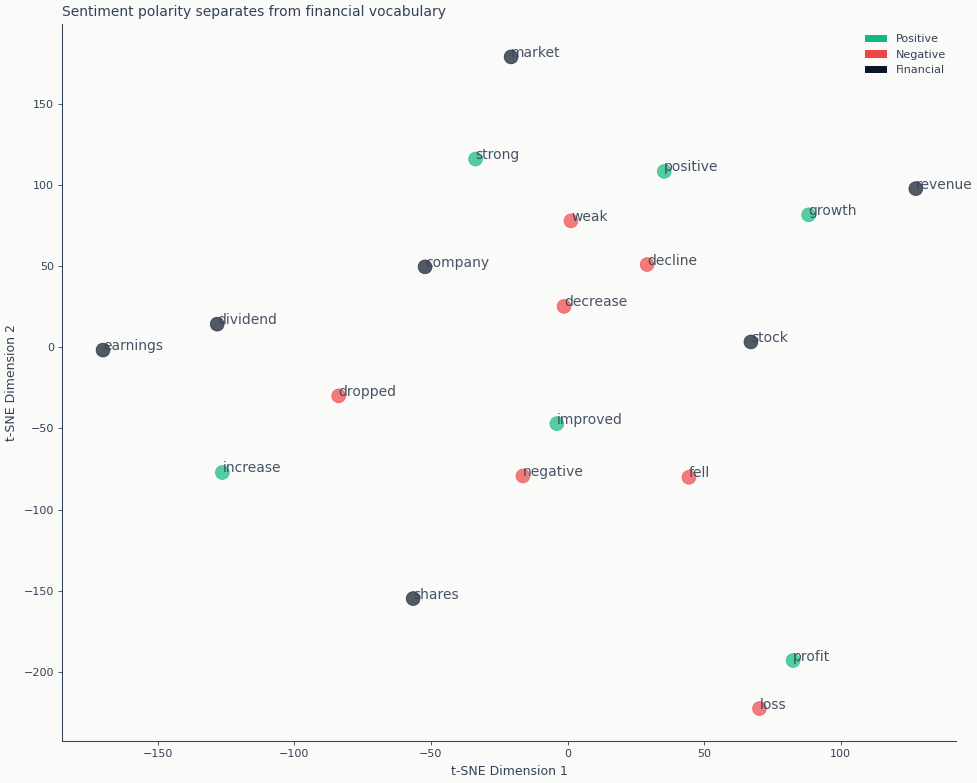

In [13]:
# t-SNE projection (requires at least 5 samples for meaningful visualization)
if len(words_to_plot) < 5:
    print(f"Too few words for t-SNE visualization (need at least 5, have {len(words_to_plot)})")
    print("Skipping visualization - train with more data or check vocabulary coverage")
    embeddings_2d = None
else:
    tsne = TSNE(
        n_components=2, perplexity=min(5, len(words_to_plot) - 1), random_state=SEED, max_iter=1000
    )
    embeddings_2d = tsne.fit_transform(embeddings_array)

# Plot (only if t-SNE succeeded)
if embeddings_2d is not None:
    from matplotlib.patches import Patch

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=colors, s=100, alpha=0.7)

    for i, word in enumerate(words_to_plot):
        ax.annotate(word, (embeddings_2d[i, 0], embeddings_2d[i, 1]), fontsize=10, alpha=0.9)

    # Legend
    legend_elements = [
        Patch(facecolor=COLORS["positive"], label="Positive"),
        Patch(facecolor=COLORS["negative"], label="Negative"),
        Patch(facecolor=COLORS["blue"], label="Financial"),
    ]
    ax.legend(handles=legend_elements, loc="upper right")

    ax.set_xlabel("t-SNE Dimension 1")
    ax.set_ylabel("t-SNE Dimension 2")
    ax.set_title("Sentiment polarity separates from financial vocabulary")
    plt.tight_layout()
    plt.show()

Even on a 2,264-sentence corpus, the Skip-gram embeddings recover the basic
polarity axis: positive terms (`profit`, `growth`, `gain`) cluster apart from
negative terms (`loss`, `decline`, `weak`). Domain nouns (`revenue`,
`earnings`, `dividend`) form a third cluster organised by topical context
rather than sentiment. The pre-trained GloVe comparison above shows where the
small-corpus model is unstable - `eur4` and `eur7` artefacts as profit
neighbours reflect tokenisation of currency amounts in the source text, not a
semantic relationship.

## Connection to Asset Embeddings

The Word2Vec training process reveals why asset embeddings work:

| Word2Vec | Asset Embeddings |
|----------|------------------|
| Words in same sentence | Stocks in same portfolio |
| Co-occurrence predicts similarity | Co-ownership predicts similarity |
| Skip-gram: predict context from word | SVD: decompose co-occurrence matrix |
| Analogies: vector arithmetic | Stock substitution: similar embeddings |

The mathematical machinery is identical - only the domain changes.
Understanding Word2Vec illuminates why institutional holdings
can reveal stock relationships that aren't obvious from fundamentals.

## Limitations of Static Embeddings

Word2Vec has three structural limitations that contextual models address:

1. **Polysemy**: One vector per word, regardless of context
   - "Apple" (company) vs "apple" (fruit) get the same vector

2. **Out-of-vocabulary**: Cannot handle unseen words
   - New tickers, technical terms not in training data

3. **No sentence understanding**: Word-level only
   - Can't directly classify "Net loss narrowed" as positive

These limitations motivate Transformers (Section 10.4), which learn
contextual embeddings where each word's vector depends on its context.

## Key Takeaways

1. **Word2Vec learns from co-occurrence**: Words in similar contexts
   get similar vectors - operationalizing the distributional hypothesis.

2. **Training is unsupervised**: No labels needed, just text.
   The model learns structure from co-occurrence patterns.

3. **Domain-specific training matters**: Financial text has different
   patterns than Wikipedia-custom training captures these.

4. **Same principle for assets**: Asset embeddings apply Word2Vec
   intuition to portfolios: stocks held together are similar.

5. **Transformers overcome limitations**: Static embeddings can't
   handle polysemy or out-of-vocabulary words - motivating BERT.

In [14]:
# Save model and results
chapter_dir = get_chapter_dir(10)
output_dir = chapter_dir / "output" / "word2vec"
output_dir.mkdir(parents=True, exist_ok=True)
model.save(str(output_dir / "word2vec_financial.model"))
print(f"Model saved to: {output_dir / 'word2vec_financial.model'}")

results_file = output_dir / "results.md"
with open(results_file, "w") as f:
    f.write("# Word2Vec Training Results\n\n")
    f.write("## Model Configuration\n")
    f.write(f"- Training data: Financial PhraseBank ({len(sentences):,} sentences)\n")
    f.write(f"- Vocabulary size: {len(model.wv):,}\n")
    f.write(f"- Embedding dimension: {model.wv.vector_size}\n")
    f.write("- Window size: 5\n")
    f.write("- Algorithm: Skip-gram with negative sampling\n\n")
    f.write("## Key Insight\n")
    f.write("The distributional hypothesis (words in similar contexts are similar)\n")
    f.write("applies equally to financial assets: stocks in similar portfolios share\n")
    f.write("investment characteristics. Word2Vec mechanics illuminate asset embeddings.\n")

print(f"Results saved to: {results_file}")

Model saved to: /app/10_text_feature_engineering/output/word2vec/word2vec_financial.model
Results saved to: /app/10_text_feature_engineering/output/word2vec/results.md
